# [LAB 07] 6. 일원분산분석
## #01. 준비작업
### 1. 패키지 설치
- pingouin 패키지와 statsmodels 패키지의 설치가 필요하다

In [1]:
%pip install --upgrade pingouin

Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip install --upgrade statsmodels

Note: you may need to restart the kernel to use updated packages.


### 2. 라이브러리 참조

In [3]:
from hossam import load_data
from helpers import *
from pandas import pivot_table

# 분산분석을 위한 라이브러리
from scipy.stats import f_oneway
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from pingouin import anova
from pingouin import welch_anova

📦 아이티윌 이광호 강사가 제작한 라이브러리를 사용중입니다.
📚 자세한 사용 방법은 https://py.hossam.kr 을 참고하세요.
📧 Email: leekh4232@gmail.com
🎬 Youtube: https://www.youtube.com/@hossam-codingclub
📝 Blog: https://blog.hossam.kr/
🔖 Version: 0.5.19


### 3. 데이터 가져오기
- tree_weight 데이터셋은 소나무 품종별 무게를 조사한 데이터이다. 소나무 품종별로 평균 무게에 차이가 있는지 분석하라.

In [4]:
origin = load_data('tree_weight')
origin

📚 소나무 품종별 무게를 조사한 데이터 (출처: 방송통신대학교 통계학개론)


,weight,group
0,4.170,A
1,5.580,A
2,5.180,A
3,6.110,A
4,4.500,A
5,4.610,A
6,5.170,A
7,4.530,A
8,5.330,A
9,5.140,A


## #02. 데이터 분포 및 가정 확인
### 1. 데이터 분포

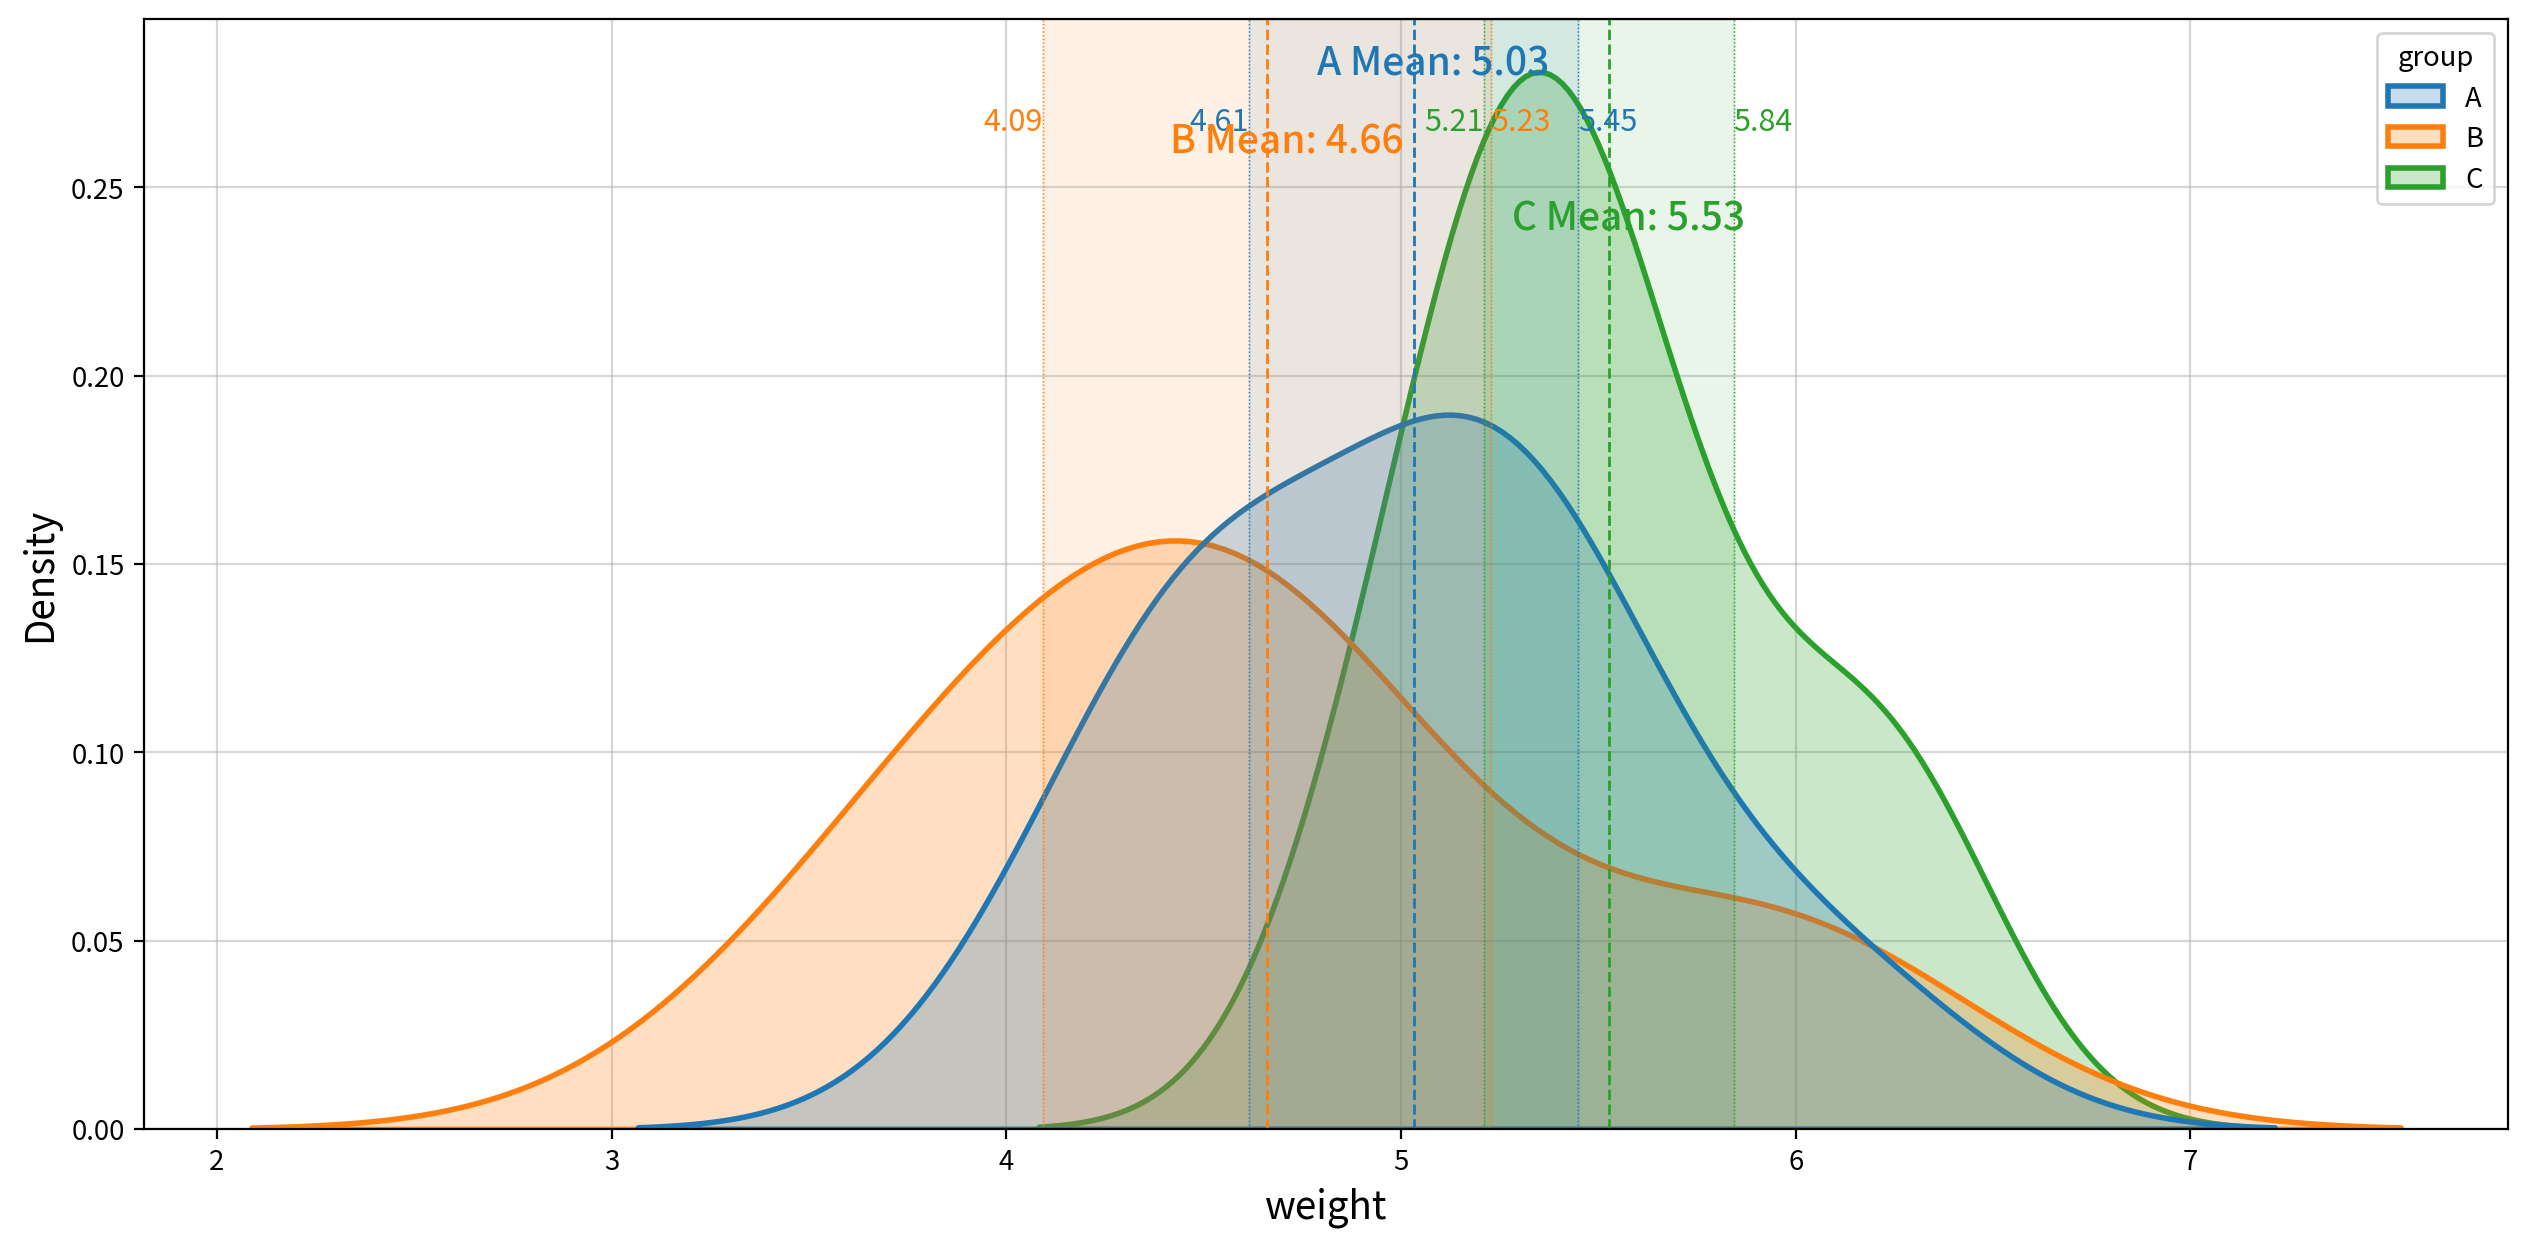

In [5]:
my_plot.kdeplot(origin, x='weight', hue='group', fill=True, meanline=True, clevel=0.95)

- 인사이트
    - 분산분석의 동기 : 평균이 B(4.66) < A(5.03) < C(5.53)로 벌어져 있어 집단 간 변동을 검정할 가치가 있음
    - 정규성 가정 : 세 분포가 종 모양 대칭 -> normaltest로 확인
    - 등분산성 가정 : 분포 폭이 비슷 -> Bartlett로 확인, 위반 시 Welch-ANOVA
    - 겹침 : 분포가 많이 겹쳐 눈으로 단정 불가, f/p로 판단 필요
    - 사후 검정 예고 : B와 C는 신뢰 수준 영역이 거의 안 겹치나 A는 애매함 -> 어느 쌍이 다른지는 사후 검정 필요

### 2. long 타입 데이터로 변환
- 가설검정의 가정 확인을 위해 long타입 데이터를 wide 타입으로 변환해야 한다.

In [6]:
df_wide = my_prep.long2wide(origin, hue='group', values='weight')
df_wide

,A,B,C
0,4.170,4.810,6.310
1,5.580,4.170,5.120
2,5.180,4.410,5.540
3,6.110,3.590,5.500
4,4.500,5.870,5.370
5,4.610,3.830,5.290
6,5.170,6.030,4.920
7,4.530,4.890,6.150
8,5.330,4.320,5.800
9,5.140,4.690,5.260


### 3. 가설 검정의 가정 확인

In [7]:
my_stats.test_assumptions(df_wide)

,test,statistic,p-value,result
field,,,,
A,normaltest,0.233,0.890,True
B,normaltest,0.968,0.616,True
C,normaltest,1.013,0.603,True
Bartlett,equal_var,2.879,0.237,True


- 정규성과 등분산성을 모두 충족한다.

## #03. 일원분산분석
### 1. SciPy 패키지를 사용하는 경우
- wide 타입의 데이터프레임을 사용해야 한다.
- 등분산성을 만족하지 않을 경우 equla_var = False 파라미터를 함께 설정하여 Welch Anova로 전환한다.

In [8]:
s,p = f_oneway(df_wide['A'], df_wide['B'], df_wide['C'], equal_var=True)
"statistic: {0:3f}, p-value: {1:.3f}".format(s,p)

'statistic: 4.846088, p-value: 0.016'

- 세 종류의 소나무 품종의 평균 무게에 대해 분산분석을 수행한 결과 귀무가설을 기각하고 대립가설을 채택한다.(p<0.05)
- 즉, 세 종류의 소나무 품종 중에서 적어도 한 품종 이상은 평균 무게가 다르다.

### 2. statsmodels 패키지를 사용하는 경우
- long 타입의 데이터프레임을 사용해야 한다.
- 데이터가 등분산성을 만족하지 않을 경우 anova_lm() 함수에 robust='hc3' 파라미터를 전달하여 Huber-White 추정치를 사용한다.
    - 원래는 Welch-ANOVA로 검정해야 하지만 statsmodels패키지는 Welch-ANOVA를 지원하지않고, Welch-ANOVA의 근사치를제공하는 Robust ANOVA를 사용한다.
    - 그래서 statsmodels를 사용한 분산분석은 추천하지 않는다.

In [9]:
# 연속형 변수 이름 ~ C(그룹 변수 이름)
lm =ols('weight ~ C(group)', data=origin).fit()
anova_result = anova_lm(lm)
anova_result

,df,sum_sq,mean_sq,F,PR(>F)
C(group),2.000,3.766,1.883,4.846,0.016
Residual,27.000,10.492,0.389,NaN,NaN


- 소나무 품종(group)에 따른 무게(weight)의 평균 차이에 대해 일원분산분석을 수행한 결과, F(𝟐,𝟐𝟕) = 𝟒.𝟖𝟒𝟔, 𝒑 = 𝟎.𝟎𝟏𝟔 < 𝟎.𝟎𝟓로 나타났다.
- 즉, 세 품종(A, B, C) 중 적어도 한품종의 평균무게는 다른 품종과 통계적으로 유의하게 다르다.
- 한계: 분산분석은 "어느 한곳 이상에서 차이가 있다"는 것만 알려줄 뿐,구체적으로 어떤 품종간에 차이가 있는지는 알려주지않는다. 
- 따라서 사후검정(post hoc)이필요하다(예: Tukey HSD, Bonferroni 등).

### 3. pingouin 패키지사용(1) - 등분산성을 충족하는 경우
- long타입의 데이터프레임을 사용해야 한다

In [10]:
anova_result = anova(data=origin, dv='weight', between='group')
anova_result

,Source,ddof1,ddof2,F,p_unc,np2
0,group,2,27,4.846,0.016,0.264


- pingouin 패키지사용(2) - 등분산성을 충족하지 않는경우
    - 데이터가 등분산성을 만족하지 않을 경우 𝑎𝑛𝑜𝑣𝑎() 함수 대신 pingouin 패키지에있는 𝑤𝑒𝑙𝑐ℎ_𝑎𝑛𝑜𝑣𝑎() 함수를 사용한다.
    - 이 예제는등분산성을 충족하는 데이터이지만 코드를 소개하기 위해 사용

In [11]:
welch_anova(data=origin, dv='weight', between='group')

,Source,ddof1,ddof2,F,p_unc,np2
0,group,2,17.128,5.181,0.017,0.264


- 소나무 품종(group)에 따른무게(weight)의 차이를 일원분산분석으로 검정한 결과, 𝑭(𝟐,𝟐𝟕)=𝟒.𝟖𝟒𝟔, 𝒑=𝟎.𝟎𝟏𝟔<𝟎.𝟎𝟓로 통계적으로 유의하였다.
- 즉, 세 품종 중 적어도 한 품종의 평균무게는 다른 품종과 유의하게 다르며, 효과크기(부분에타제곱) η²ₚ = 0.264로 품종이 무게변동의 약 26%를 설명하는 큰 효과를 보였다.

### 04. 모듈화 기능 확인
- 등분산성 가정 충족에 따라 Normal ANOVA가 수행된다.

In [13]:
my_stats.anova_oneway(origin, y='weight', between='group')

,test,Source,ddof1,ddof2,F,p_unc,np2,effect_size
0,anova,group,2,27,4.846,0.016,0.264,Large


- 검정선택 : 'test=anova' -> 등분산성을 충족하여 일반 일원분산분석을 자동적용(위반 시 'welch_anova'로 전환)
- 유의성 : F(2,27)=4.846, p=0.016<0.05 -> 귀무가설 기각, 세품종 중 적어도 한 품종의 평균 무게는 다르다
- 효과 크기 : np2=0.264 -> Large 품종 차이가 무게 변동의 약 26%를 설명, 통계적 유의성을 넘어 실질적으로도 큰 효과
- 다음단계 : ANOVA는 '어딘가 차이가 있다'까지만 말해주므로, 어느 쌍이 다른지는 사후검정 등으로 확인 필요